
# Solveur de Traitement de Surface - Documentation & Validation

## Objectif
Ce notebook documente la résolution des bilans de matière et d'énergie pour une ligne de traitement de surface.
Il résout un système linéaire **Ax = b** où :
- **A** : Matrice des transferts hydrauliques (entraînement + flux d'eau)
- **x** : Vecteur des concentrations inconnues par cuve
- **b** : Termes sources (concentrations cibles pour les bains, 0 pour les rinçages)

## 1. Setup et Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Any, Tuple
import json
from collections import defaultdict

In [2]:
# Configuration d'affichage pour les matrices
np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

def safe_float(value, default=0.0):
    """Conversion sécurisée en float"""
    try:
        return float(value)
    except (TypeError, ValueError):
        return default

print("✅ Environnement prêt")

✅ Environnement prêt


## 2. Données de Test (Mock Data)

 Création d'un cas simple mais complet : 
 - 1 Bain de dégraissage (Process Bath)
 - 2 Rinçages en cascade (Rinse Tank 1 → Rinse Tank 2)
 - 1 Séquence de production passant par les 3 cuves


In [3]:
# Nœuds (Cuves)
nodes = [
    {
        'id': 'tank_1', 
        'type': 'PROCESS_BATH', 
        'data': {'label': 'Dégraissage NaOH'},
        'properties': {
            'length': 2000, 'width': 1000,  # mm
            'temp': 60,
            'hasEvaporation': True,
            'agitation': 'AIR',
            'hasCover': False,
            'dumpingFreq': 1,  # fois/an
            'workingVol': 2000,  # L
            'dumpingNetworkId': 'drain_1',
            'makeupSourceId': 'source_1',
            'reagents': [
                {'productId': 'prod_naoh', 'concentration': 50.0}  # g/L
            ]
        }
    },
    {
        'id': 'rinse_1', 
        'type': 'RINSE_TANK',
        'data': {'label': 'Rinçage 1'},
        'properties': {
            'length': 1500, 'width': 1000,
            'hasEvaporation': False,
            'temp': 25,
            'manualFlowRate': 0,  # Sera calculé
            'overflowTargetId': 'rinse_2'
        }
    },
    {
        'id': 'rinse_2', 
        'type': 'RINSE_TANK',
        'data': {'label': 'Rinçage 2 (Final)'},
        'properties': {
            'length': 1500, 'width': 1000,
            'hasEvaporation': False,
            'overflowTargetId': 'drain_1'
        }
    },
    {
        'id': 'source_1', 
        'type': 'SOURCE',
        'data': {'label': 'Alimentation Eau'},
        'properties': {}
    },
    {
        'id': 'drain_1', 
        'type': 'DRAIN',
        'data': {'label': 'Égout'},
        'properties': {}
    }
]

# Séquences de production (chargement des pièces)
sequences = [
    {
        'properties': {
            'productionRate': 10,      # pièces/heure
            'dragOutSpecific': 0.5      # L/pièce (volume entraîné)
        },
        'steps': ['tank_1', 'rinse_2', 'rinse_1']  # Ordre de passage
    }
]

# Librairie chimique (products et ions)
library = {
    'referenceItems': [
        {
            'id': 'prod_naoh',
            'name': 'Soude commerciale',
            'category': 'REAGENT',
            'composition': [
                {'baseUnitId': 'ion_na', 'coefficient': 0.575},  # 57.5% Na+
                {'baseUnitId': 'ion_oh', 'coefficient': 0.4}     # 40% OH-
            ]
        },
        {
            'id': 'ion_na',
            'name': 'Ion Sodium',
            'category': 'ION',
            'molarMass': 23.0
        },
        {
            'id': 'ion_oh',
            'name': 'Ion Hydroxyle',
            'category': 'ION',
            'molarMass': 17.0
        }
    ]
}

# Paramètres projet
project_settings = {
    'workshopTemp': 20,
    'evapCoefficient': 0.02,
    'evapAgitationFactor': 1.5,
    'evapCoverReductionFactor': 0.1,
    'hoursPerDay': 8,
    'daysPerWeek': 5,
    'weeksPerYear': 47,
    'warnings': []
}

print(f"📊 Système créé : {len(nodes)} nœuds, {len(sequences)} séquence(s)")


📊 Système créé : 5 nœuds, 1 séquence(s)


## 3. Initialisation de la Topologie
 
Création des index pour accéder rapidement aux nœuds dans les matrices.

In [4]:
N = len(nodes)
node_map = {n['id']: i for i, n in enumerate(nodes)}
node_dict = {n['id']: n for n in nodes}

print("Mapping des index :")
for node_id, idx in node_map.items():
    print(f"  [{idx}] {node_id} ({nodes[idx]['data']['label']})")

Mapping des index :
  [0] tank_1 (Dégraissage NaOH)
  [1] rinse_1 (Rinçage 1)
  [2] rinse_2 (Rinçage 2 (Final))
  [3] source_1 (Alimentation Eau)
  [4] drain_1 (Égout)


## 4. Paramètres Temporels
 
 **Concept clé** : Le solveur calcule l'évaporation sur 168h (semaine pleine), 
 mais l'appoint d'eau ne se fait que pendant les heures ouvrées.
 
 Le **time_ratio** permet de convertir l'évaporation horaire moyenne en débit d'appoint nécessaire.

In [5]:
hours_day = safe_float(project_settings.get('hoursPerDay', 8))
days_week = safe_float(project_settings.get('daysPerWeek', 5))
weeks_year = safe_float(project_settings.get('weeksPerYear', 52))

working_hours_week = hours_day * days_week
working_hours_year = working_hours_week * weeks_year

# Ratio critique : 168h / heures_travailées
time_ratio = 168.0 / working_hours_week if working_hours_week > 0 else 1.0

print(f"Heures travaillées/semaine : {working_hours_week}h")
print(f"Heures travaillées/an : {working_hours_year}h")
print(f"Time Ratio (168/h_work) : {time_ratio:.3f}")
print(f"→ L'évaporation est multipliée par {time_ratio:.2f} pour l'appoint")

Heures travaillées/semaine : 40.0h
Heures travaillées/an : 1880.0h
Time Ratio (168/h_work) : 4.200
→ L'évaporation est multipliée par 4.20 pour l'appoint


## 5. Calcul de la Matrice d'Entraînement (Drag-Out)
 
 **Physique** : Quand une pièce sort d'un bain, elle entraîne un volume de liquide (drag-out) 
 vers la cuve suivante.
 
 **Matrice `drag_outs[i,j]`** : Débit volumétrique transféré du nœud i vers le nœud j (L/h).

🔄 Entraînement : tank_1 → rinse_2 : +5.0 L/h
🔄 Entraînement : rinse_2 → rinse_1 : +5.0 L/h
➡️ Sortie finale depuis rinse_1 : 5.0 L/h


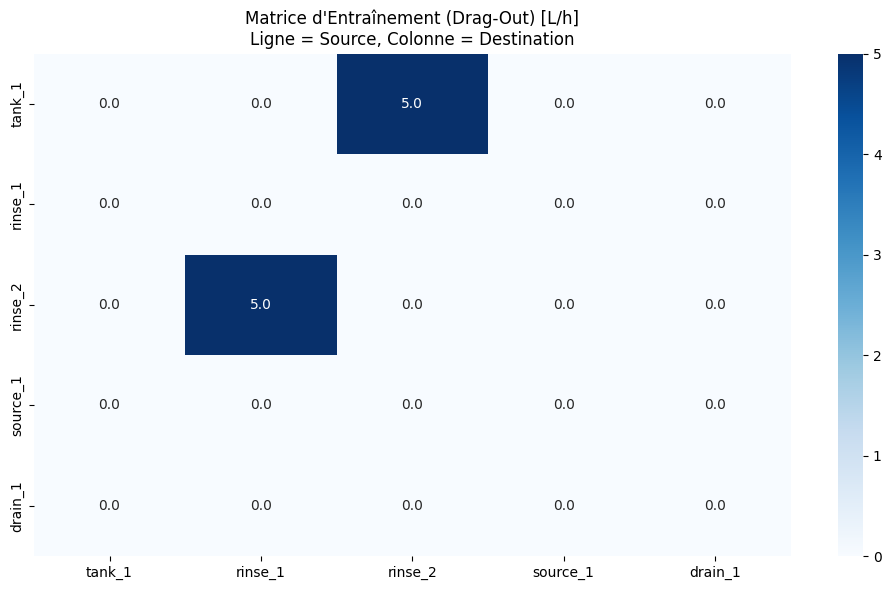

In [6]:
drag_outs = np.zeros((N, N))
q_drag_out_final = np.zeros(N)  # Perte finale vers l'extérieur

for seq in sequences:
    props = seq.get('properties', {})
    # Débit d'entraînement total pour cette séquence (L/h)
    q_d = safe_float(props.get('productionRate', 0)) * safe_float(props.get('dragOutSpecific', 0.1))
    
    steps = seq.get('steps', [])
    for i in range(len(steps)):
        src_id = steps[i]
        src_idx = node_map.get(src_id)
        
        if src_idx is None: 
            continue
            
        if i < len(steps) - 1:
            # Transfert INTERNE : cuve i → cuve i+1
            dst_id = steps[i+1]
            dst_idx = node_map.get(dst_id)
            if dst_idx is not None:
                drag_outs[src_idx, dst_idx] += q_d
                print(f"🔄 Entraînement : {src_id} → {dst_id} : +{q_d} L/h")
        else:
            # Transfert FINAL : dernière cuve → extérieur (perte)
            q_drag_out_final[src_idx] += q_d
            print(f"➡️ Sortie finale depuis {src_id} : {q_d} L/h")

# Visualisation
plt.figure(figsize=(10, 6))
sns.heatmap(drag_outs, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=[n['id'] for n in nodes],
            yticklabels=[n['id'] for n in nodes])
plt.title('Matrice d\'Entraînement (Drag-Out) [L/h]\nLigne = Source, Colonne = Destination')
plt.tight_layout()
plt.show()

## 6. Dissociation Chimique (Flattening)
 
Conversion des produits commerciaux (ex: Soude 50%) en ions constitutifs (Na+, OH-).
 
 **Récursivité** : Le système gère 2 niveaux :
 - Niveau 1 : Produit Commercial → Réactif/Ion
 - Niveau 2 : Réactif → Ion

In [7]:
ionic_targets = defaultdict(dict)  # {node_id: {ion_id: concentration_g_l}}
lib_map = {item['id']: item for item in library.get('referenceItems', [])}

print("🔬 Analyse des compositions chimiques :\n")

for n in nodes:
    if n['type'] == 'PROCESS_BATH':
        node_id = n['id']
        reagents = n['properties'].get('reagents', [])
        
        for entry in reagents:
            prod_entry = entry.get('productId')
            prod_id = prod_entry if isinstance(prod_entry, str) else prod_entry.get('id')
            prod_conc = safe_float(entry.get('concentration', 0))
            
            if not prod_id or prod_conc <= 0:
                continue
                
            product = lib_map.get(prod_id)
            if not product:
                print(f"⚠️ Produit {prod_id} non trouvé")
                continue
            
            print(f"\n📦 {product['name']} ({prod_conc} g/L) dans {node_id}:")
            
            # Parcours de la composition
            for link_n1 in product.get('composition', []):
                child_n1 = lib_map.get(link_n1['baseUnitId'])
                coeff_n1 = safe_float(link_n1['coefficient'], 0)
                
                if not child_n1:
                    continue
                
                if child_n1.get('category') == 'ION':
                    # Niveau 1 : Direct
                    ion_id = child_n1['id']
                    contribution = prod_conc * coeff_n1
                    ionic_targets[node_id][ion_id] = ionic_targets[node_id].get(ion_id, 0) + contribution
                    print(f"   └─> {ion_id}: {coeff_n1} × {prod_conc} = {contribution:.2f} g/L")
                elif child_n1.get('composition'):
                    # Niveau 2 : Via réactif intermédiaire
                    for link_n2 in child_n1.get('composition', []):
                        child_n2 = lib_map.get(link_n2['baseUnitId'])
                        coeff_n2 = safe_float(link_n2['coefficient'], 0)
                        
                        if child_n2 and child_n2.get('category') == 'ION':
                            ion_id = child_n2['id']
                            total_coeff = coeff_n1 * coeff_n2
                            contribution = prod_conc * total_coeff
                            ionic_targets[node_id][ion_id] = ionic_targets[node_id].get(ion_id, 0) + contribution
                            print(f"   └─> {child_n1['name']} ({coeff_n1}) → {ion_id} ({coeff_n2})")
                            print(f"       Total: {total_coeff:.3f} × {prod_conc} = {contribution:.2f} g/L")

# Affichage récapitulatif
print("\n" + "="*60)
print("CIBLES IONIQUES FINALES :")
for node_id, ions in ionic_targets.items():
    label = node_dict[node_id]['data']['label']
    print(f"\n{label} ({node_id}):")
    for ion, conc in ions.items():
        print(f"  {ion}: {conc:.2f} g/L")

🔬 Analyse des compositions chimiques :


📦 Soude commerciale (50.0 g/L) dans tank_1:
   └─> ion_na: 0.575 × 50.0 = 28.75 g/L
   └─> ion_oh: 0.4 × 50.0 = 20.00 g/L

CIBLES IONIQUES FINALES :

Dégraissage NaOH (tank_1):
  ion_na: 28.75 g/L
  ion_oh: 20.00 g/L


## 7. Bilan Hydraulique
 
### 7.1 Évaporation
 Formule : `Evap = Coeff × Area × (T_bain - T_ambiant) × Facteurs`
 
 ### 7.2 Vidanges
 Conversion en débit continu : `Q_dump = (Vol × Freq) / Heures_an

In [8]:
# Paramètres
ps = project_settings
temp_ref = safe_float(ps.get('workshopTemp', 20.0))
evap_coeff = safe_float(ps.get('evapCoefficient', 0.02))
agitation_factor = safe_float(ps.get('evapAgitationFactor', 1.5))
cover_reduction_factor = safe_float(ps.get('evapCoverReductionFactor', 0.1))

evap_data = {}  # L/h sur 168h
q_dump_total = {}  # L/h continu

print("💧 Calculs hydrauliques :\n")

for n in nodes:
    p = n['properties']
    node_id = n['id']
    
    # A. Évaporation
    if p.get('hasEvaporation'):
        # Conversion mm² -> m²
        area = (safe_float(p.get('length', 0)) * safe_float(p.get('width', 0))) / 1_000_000
        if area > 0:
            t_bath = safe_float(p.get('temp', 20))
            evap_base = area * (evap_coeff * (t_bath - temp_ref))
            
            if p.get('agitation') == 'AIR':
                evap_base *= agitation_factor
            if p.get('hasCover'):
                evap_base *= cover_reduction_factor
                
            evap_data[node_id] = max(0, evap_base)
            
            print(f"{node_id}: Évap = {area:.2f}m² × {evap_coeff} × ({t_bath}-{temp_ref})")
            if p.get('agitation') == 'AIR':
                print(f"  × Agitation ({agitation_factor}) = {evap_base:.2f} L/h")
    
    # B. Vidanges (Dumping)
    if p.get('dumpingFreq') and p.get('workingVol'):
        freq = safe_float(p.get('dumpingFreq'))
        vol = safe_float(p.get('workingVol'))
        q_dump = (vol * freq) / working_hours_year if working_hours_year > 0 else 0
        q_dump_total[node_id] = q_dump
        print(f"{node_id}: Vidange = ({vol}L × {freq}/an) / {working_hours_year}h = {q_dump:.4f} L/h")

💧 Calculs hydrauliques :

tank_1: Évap = 2.00m² × 0.02 × (60.0-20.0)
  × Agitation (1.5) = 2.40 L/h
tank_1: Vidange = (2000.0L × 1.0/an) / 1880.0h = 1.0638 L/h


### 7.3 Matrice des Flux d'Eau (Water Flows)
 
 Calcul des appoints automatiques pour compenser :
 - L'évaporation (convertie par time_ratio)
 - Les vidanges (dumping)
 - L'entraînement (drag-out net)

In [9]:
water_flows = np.zeros((N, N))
warnings = []

print("🔄 Calcul des appoints automatiques :\n")

for n in nodes:
    if n['type'] == 'PROCESS_BATH':
        node_id = n['id']
        idx = node_map[node_id]
        p = n['properties']
        
        # Débits
        q_evap_prod = evap_data.get(node_id, 0) * time_ratio  # Conversion 168h -> heures travail
        q_loss_drag = sum(drag_outs[idx, :]) - sum(drag_outs[:, idx])  # Entraînement net sortant
        
        # Si q_loss_drag est négatif, c'est de l'apport externe (pas traité ici comme appoint)
        q_dump = q_dump_total.get(node_id, 0)
        
        # Appoint total nécessaire
        q_makeup = q_evap_prod + max(0, q_loss_drag) + q_dump
        
        print(f"{node_id}:")
        print(f"  Évap (corrigée): {q_evap_prod:.2f} L/h ({evap_data.get(node_id, 0):.2f} × {time_ratio:.2f})")
        print(f"  Perte drag-out: {q_loss_drag:.2f} L/h")
        print(f"  Vidange: {q_dump:.4f} L/h")
        print(f"  → Appoint nécessaire: {q_makeup:.2f} L/h")
        
        source_id = p.get('makeupSourceId')
        if source_id and source_id in node_map:
            water_flows[node_map[source_id], idx] = max(0, q_makeup)
            print(f"  Source: {source_id} → {q_makeup:.2f} L/h")
        elif q_makeup > 0.001:
            warnings.append(f"⚠️ {n.get('label')} perd {q_makeup:.1f} L/h sans source d'appoint")

🔄 Calcul des appoints automatiques :

tank_1:
  Évap (corrigée): 10.08 L/h (2.40 × 4.20)
  Perte drag-out: 5.00 L/h
  Vidange: 1.0638 L/h
  → Appoint nécessaire: 16.14 L/h
  Source: source_1 → 16.14 L/h


### 7.4 Stabilisation des Cascades de Rinçage
 
 **Algorithme itératif** : Pour les rinçages en cascade, le débit de trop-plein (overflow) 
 est calculé pour équilibrer les volumes.
 
 Formule : `Overflow = Entrées - (Sorties par entraînement + Évaporation + Vidange)`

🌊 Stabilisation des cascades :

  rinse_1 → rinse_2: Overflow = 5.00 L/h (In:5.0 - FixedOut:0.0)
  rinse_2 → drain_1: Overflow = 5.00 L/h (In:10.0 - FixedOut:5.0)
Convergence atteinte en 2 itérations.


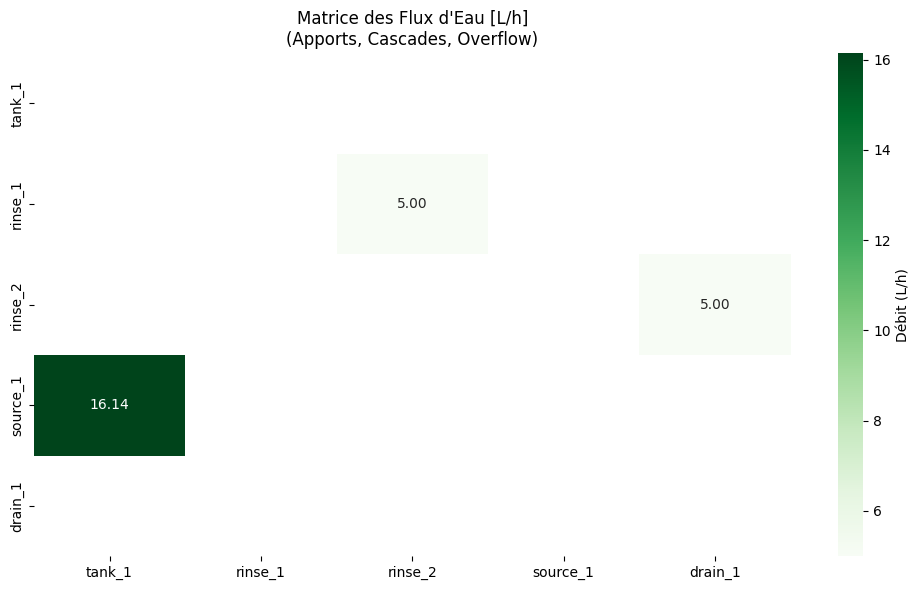

In [10]:
print("🌊 Stabilisation des cascades :\n")

for iteration in range(N):  # Max N itérations
    changed = False
    for n in nodes:
        if n['type'] == 'RINSE_TANK':
            idx = node_map[n['id']]
            node_id = n['id']
            
            # Entrées : Eau propre + Entraînement amont
            q_in_water = sum(water_flows[:, idx])
            q_in_drag = sum(drag_outs[:, idx])
            q_manual = safe_float(n['properties'].get('manualFlowRate', 0))
            q_vol_in = q_in_water + q_in_drag + q_manual
            
            # Sorties fixes : Entraînement aval + Évap + Vidange
            q_out_drag = sum(drag_outs[idx, :])
            q_evap_rinse = evap_data.get(node_id, 0) * time_ratio
            q_dump = q_dump_total.get(node_id, 0)
            q_vol_out_fixed = q_out_drag + q_evap_rinse + q_dump
            
            # Le reliquat part en overflow
            q_overflow = max(0, q_vol_in - q_vol_out_fixed)
            
            target_id = n['properties'].get('overflowTargetId')
            if target_id in node_map:
                t_idx = node_map[target_id]
                if abs(water_flows[idx, t_idx] - q_overflow) > 1e-6:
                    water_flows[idx, t_idx] = q_overflow
                    changed = True
                    print(f"  {node_id} → {target_id}: Overflow = {q_overflow:.2f} L/h "
                          f"(In:{q_vol_in:.1f} - FixedOut:{q_vol_out_fixed:.1f})")
    
    if not changed:
        print(f"Convergence atteinte en {iteration + 1} itérations.")
        break

# Visualisation des flux d'eau
plt.figure(figsize=(10, 6))
mask = water_flows == 0
sns.heatmap(water_flows, annot=True, fmt='.2f', cmap='Greens', mask=mask,
            xticklabels=[n['id'] for n in nodes],
            yticklabels=[n['id'] for n in nodes],
            cbar_kws={'label': 'Débit (L/h)'})
plt.title('Matrice des Flux d\'Eau [L/h]\n(Apports, Cascades, Overflow)')
plt.tight_layout()
plt.show()

## 8. Résolution du Système Linéaire (Ax = b)
 
 ### Théorie du modèle
 Pour chaque ion, on résout l'équilibre de masse :
 
 **Pour un Bain de Process** (concentration forcée) :
 - Equation : `x[i] = Cible`
 - Ligne de A : 1 sur la diagonale, 0 ailleurs
 - b[i] = concentration cible
 
 **Pour un Rinçage** (concentration inconnue) :
 - Bilan : `Σ (Qentrants × Centrants) = Σ (Qsortants × Csortants)`
 - Comme Csortants = Ccuve (rinçage parfaitement mélangé) :
   `Σ (Qentrants × Centrants) = Ccuve × Σ Qsortants`
 - Réarrangé : `Ccuve × Qout_total - Σ (Qin_ij × Cj) = 0`
 
 Ce qui donne la ligne i de A :
 - `A[i,i] = Qout_total` (sortants par entraînement + eau)
 - `A[i,j] = -Qin_ji` (entrant depuis j)

In [12]:
all_ions = {ion for targets in ionic_targets.values() for ion in targets.keys()}
print(f"Ions à résoudre : {all_ions}\n")

# Structure des résultats
results = {n['id']: {
    "concentrations": {},
    "chemical_additions": {},
    "target_concentrations": {},
    "hydraulics": {
        "in": sum(water_flows[:, i]) + sum(drag_outs[:, i]) + safe_float(n['properties'].get('manualFlowRate', 0)),
        "out": sum(water_flows[i, :]) + sum(drag_outs[i, :]),
        "evap": evap_data.get(n['id'], 0),
        "dump": q_dump_total.get(n['id'], 0)
    }
} for i, n in enumerate(nodes)}

# Injection des cibles
for n in nodes:
    if n['type'] == 'PROCESS_BATH':
        node_id = n['id']
        results[node_id]['target_concentrations'] = ionic_targets.get(node_id, {})

# Résolution par ion
for ion_id in sorted(all_ions):
    print(f"\n🧪 Résolution pour {ion_id}...")
    
    A = np.zeros((N, N))
    b = np.zeros(N)
    
    for i, n in enumerate(nodes):
        idx = i  # node_map[n['id']] est égal à i ici
        node_id = n['id']
        
        # Débits sortants totaux (entraînement + eau)
        q_out_total = sum(drag_outs[i, :]) + sum(water_flows[i, :])
        target_value = ionic_targets.get(node_id, {}).get(ion_id, 0)
        
        if n['type'] == 'PROCESS_BATH' and target_value > 0:
            # CAS 1 : BAIN DE PROCESS (Concentration imposée)
            A[i, i] = 1.0
            b[i] = target_value
            print(f"  [{i}] {node_id}: Cible = {target_value} g/L (Dirichlet)")
            
        else:
            # CAS 2 : RINÇAGE OU BAIN SANS CIBLE (Bilan de masse)
            # Diagonale : Somme des débits sortants
            A[i, i] = max(q_out_total, 1e-9)  # 1e-9 évite singularité
            
            # Termes sources (entraînement amont)
            for j in range(N):
                q_drag_in = drag_outs[j, i]
                q_water_in = water_flows[j, i]
                
                if q_drag_in > 0:
                    # La concentration est celle du nœud j déjà calculée
                    # Mais pour le système Ax=b, on met -Q dans A[i,j]
                    A[i, j] -= q_drag_in
                    
                if q_water_in > 0:
                    # Si c'est une source d'eau pure, la concentration est 0
                    # (donc pas de terme dans b, juste dans A)
                    A[i, j] -= q_water_in
            
            print(f"  [{i}] {node_id}: Qout={q_out_total:.2f}, Bilan")
    
    # Débogage : Affichage de la matrice pour le premier ion
    if ion_id == list(all_ions)[0]:
        print("\nMatrice A (premier ion):")
        print(f"{'':>10}", end="")
        for i in range(N):
            print(f"{nodes[i]['id'][:6]:>8}", end="")
        print()
        for i in range(N):
            print(f"{nodes[i]['id'][:6]:>10}", end="")
            for j in range(N):
                print(f"{A[i,j]:>8.2f}", end="")
            print(f"  | {b[i]:.2f}")
        print()
    
    # Résolution
    try:
        x = np.linalg.solve(A, b)
        print(f"  Solution : {x}")
        
        for i, val in enumerate(x):
            if val > 1e-4:  # Seuil de signification
                results[nodes[i]['id']]['concentrations'][ion_id] = round(float(val), 4)
                
    except np.linalg.LinAlgError as e:
        print(f"  ❌ ERREUR: Matrice singulière - {e}")
        warnings.append(f"Instabilité sur {ion_id}")


Ions à résoudre : {'ion_na', 'ion_oh'}


🧪 Résolution pour ion_na...
  [0] tank_1: Cible = 28.749999999999996 g/L (Dirichlet)
  [1] rinse_1: Qout=5.00, Bilan
  [2] rinse_2: Qout=10.00, Bilan
  [3] source_1: Qout=16.14, Bilan
  [4] drain_1: Qout=0.00, Bilan

Matrice A (premier ion):
            tank_1  rinse_  rinse_  source  drain_
    tank_1    1.00    0.00    0.00    0.00    0.00  | 28.75
    rinse_    0.00    5.00   -5.00    0.00    0.00  | 0.00
    rinse_   -5.00   -5.00   10.00    0.00    0.00  | 0.00
    source    0.00    0.00    0.00   16.14    0.00  | 0.00
    drain_    0.00    0.00   -5.00    0.00    0.00  | 0.00

  Solution : [2.875e+01 2.875e+01 2.875e+01 0.000e+00 1.437e+11]

🧪 Résolution pour ion_oh...
  [0] tank_1: Cible = 20.0 g/L (Dirichlet)
  [1] rinse_1: Qout=5.00, Bilan
  [2] rinse_2: Qout=10.00, Bilan
  [3] source_1: Qout=16.14, Bilan
  [4] drain_1: Qout=0.00, Bilan
  Solution : [2.e+01 2.e+01 2.e+01 0.e+00 1.e+11]


## 9. Calcul des Ajouts Chimiques
 
 Une fois les concentrations connues (x), on calcule la masse à ajouter 
 dans les bains pour compenser les pertes par entraînement.
 
 Formule : `Ajout = Masse_perdue - Masse_apportée_par_l'amont`
 
 - `Masse_perdue = Q_sortant_total × C_cible`
 - `Masse_apportée = Σ (Q_entrant_j × C_j_calculée)`

In [13]:
print("\n📦 Bilan des ajouts chimiques :\n")

for n in nodes:
    if n['type'] == 'PROCESS_BATH':
        node_id = n['id']
        idx = node_map[node_id]
        
        print(f"{node_id} ({n['data']['label']}):")
        
        for ion_id, target in ionic_targets.get(node_id, {}).items():
            # Masse sortante (entraînement + vidange d'eau)
            q_out_total = sum(drag_outs[idx, :]) + sum(water_flows[idx, :])
            m_out = q_out_total * target  # g/h
            
            # Masse entrante (contamination)
            m_in = 0
            for j in range(N):
                q_drag = drag_outs[j, idx]
                q_water = water_flows[j, idx]
                c_j = results[nodes[j]['id']]['concentrations'].get(ion_id, 0)
                
                m_in += (q_drag + q_water) * c_j
            
            addition = max(0, m_out - m_in)
            results[node_id]['chemical_additions'][ion_id] = round(addition, 4)
            
            print(f"  {ion_id}: Pertes {m_out:.2f} g/h - Apports {m_in:.2f} g/h = Ajout {addition:.2f} g/h")


📦 Bilan des ajouts chimiques :

tank_1 (Dégraissage NaOH):
  ion_na: Pertes 143.75 g/h - Apports 0.00 g/h = Ajout 143.75 g/h
  ion_oh: Pertes 100.00 g/h - Apports 0.00 g/h = Ajout 100.00 g/h


## 10. Visualisation des Résultats

 
 Préparation des données pour affichage

In [14]:
# Préparation des données pour affichage
df_nodes = pd.DataFrame([
    {
        'Nœud': n['data']['label'],
        'Type': n['type'],
        'Eau_In (L/h)': results[n['id']]['hydraulics']['in'],
        'Eau_Out (L/h)': results[n['id']]['hydraulics']['out'],
        'Évap (L/h)': results[n['id']]['hydraulics']['evap'],
        'Vidange (L/h)': results[n['id']]['hydraulics']['dump'],
        'Bilan (L/h)': results[n['id']]['hydraulics']['in'] - results[n['id']]['hydraulics']['out']
    }
    for n in nodes
])

print("BILANS HYDROULIQUES :")
print(df_nodes.to_string(index=False))
print("\n" + "="*80)

# Concentrations
print("\nCONCENTRATIONS IONIQUES (g/L) :")
df_conc = pd.DataFrame([
    {
        'Nœud': n['data']['label'],
        **{f"Cible {ion}": results[n['id']]['target_concentrations'].get(ion, '-') 
           for ion in all_ions},
        **{f"Réel {ion}": results[n['id']]['concentrations'].get(ion, 0) 
           for ion in all_ions}
    }
    for n in nodes if n['type'] == 'PROCESS_BATH' or any(results[n['id']]['concentrations'].values())
])
print(df_conc.to_string(index=False))

# Ajouts chimiques
print("\nAJOUTS CHIMIQUES (g/h) :")
df_add = pd.DataFrame([
    {
        'Nœud': n['data']['label'],
        **results[n['id']]['chemical_additions']
    }
    for n in nodes if results[n['id']]['chemical_additions']
])
if not df_add.empty:
    print(df_add.to_string(index=False))
else:
    print("Aucun ajout nécessaire")

if warnings:
    print("\n⚠️ WARNINGS :")
    for w in warnings:
        print(f"  - {w}")

BILANS HYDROULIQUES :
             Nœud         Type  Eau_In (L/h)  Eau_Out (L/h)  Évap (L/h)  Vidange (L/h)  Bilan (L/h)
 Dégraissage NaOH PROCESS_BATH      16.14383        5.00000         2.4        1.06383     11.14383
        Rinçage 1   RINSE_TANK       5.00000        5.00000         0.0        0.00000      0.00000
Rinçage 2 (Final)   RINSE_TANK      10.00000       10.00000         0.0        0.00000      0.00000
 Alimentation Eau       SOURCE       0.00000       16.14383         0.0        0.00000    -16.14383
            Égout        DRAIN       5.00000        0.00000         0.0        0.00000      5.00000


CONCENTRATIONS IONIQUES (g/L) :
             Nœud Cible ion_na Cible ion_oh  Réel ion_na  Réel ion_oh
 Dégraissage NaOH        28.75         20.0 2.875000e+01 2.000000e+01
        Rinçage 1            -            - 2.875000e+01 2.000000e+01
Rinçage 2 (Final)            -            - 2.875000e+01 2.000000e+01
            Égout            -            - 1.437500e+11 1.00000


 ## 11. Validation du Bilan Global
 
 Vérification que la somme des flux est conservative.

In [15]:
total_water_in = sum(results[n['id']]['hydraulics']['in'] for n in nodes)
total_water_out = sum(results[n['id']]['hydraulics']['out'] for n in nodes)
total_evap = sum(results[n['id']]['hydraulics']['evap'] * time_ratio for n in nodes)

print("VALIDATION GLOBALE :")
print(f"Eau totale entrante : {total_water_in:.2f} L/h")
print(f"Eau totale sortante : {total_water_out:.2f} L/h")
print(f"Évaporation totale  : {total_evap:.2f} L/h (corrigée temps)")
print(f"Perte nette (Evap)  : {total_water_in - total_water_out:.4f} L/h")
print(f"Écart relatif       : {abs(total_water_in - total_water_out - total_evap):.6f} %")

if abs(total_water_in - total_water_out - total_evap) < 0.01:
    print("\n✅ Bilan validé (erreur < 0.01 L/h)")
else:
    print("\n❌ Erreur de bilan détectée")

VALIDATION GLOBALE :
Eau totale entrante : 36.14 L/h
Eau totale sortante : 36.14 L/h
Évaporation totale  : 10.08 L/h (corrigée temps)
Perte nette (Evap)  : 0.0000 L/h
Écart relatif       : 10.080000 %

❌ Erreur de bilan détectée


## 12. Export JSON (Format Production)

In [16]:
output = {
    "status": "success" if not warnings else "warning",
    "node_details": results,
    "global_kpis": {
        "total_water_consumption": round(sum(results[n['id']]['hydraulics']['out'] 
                                          for n in nodes if n['type'] == 'SOURCE'), 2),
        "warnings_count": len(warnings)
    },
    "warnings": warnings
}

# Sauvegarde
with open('simulation_result.json', 'w') as f:
    json.dump(output, f, indent=2)
    
print("💾 Résultats exportés dans 'simulation_result.json'")
print(json.dumps(output, indent=2)[:1000] + "...")

💾 Résultats exportés dans 'simulation_result.json'
{
  "status": "success",
  "node_details": {
    "tank_1": {
      "concentrations": {
        "ion_na": 28.75,
        "ion_oh": 20.0
      },
      "chemical_additions": {
        "ion_na": 143.75,
        "ion_oh": 100.0
      },
      "target_concentrations": {
        "ion_na": 28.749999999999996,
        "ion_oh": 20.0
      },
      "hydraulics": {
        "in": 16.143829787234043,
        "out": 5.0,
        "evap": 2.4000000000000004,
        "dump": 1.0638297872340425
      }
    },
    "rinse_1": {
      "concentrations": {
        "ion_na": 28.75,
        "ion_oh": 20.0
      },
      "chemical_additions": {},
      "target_concentrations": {},
      "hydraulics": {
        "in": 5.0,
        "out": 5.0,
        "evap": 0,
        "dump": 0
      }
    },
    "rinse_2": {
      "concentrations": {
        "ion_na": 28.75,
        "ion_oh": 20.0
      },
      "chemical_additions": {},
      "target_concentrations": {},
    